In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
!pwd

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
/home/angelika/Desktop/8_term/R_D/python_utils


In [30]:
img = cv2.imread("/home/angelika/Desktop/8_term/R_D/General_C/DATA/08_04/frame_rgb_2.jpg", cv2.IMREAD_GRAYSCALE)

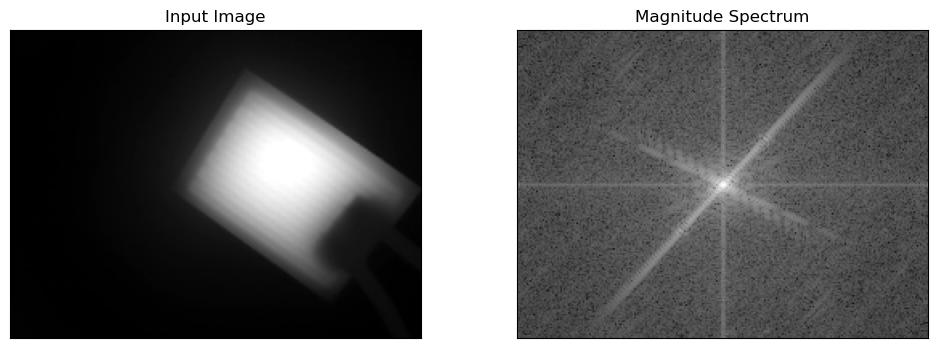

In [31]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

magnitude_spectrum = 20*np.log(np.abs(fshift))

plt.figure(figsize=(12,4))
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

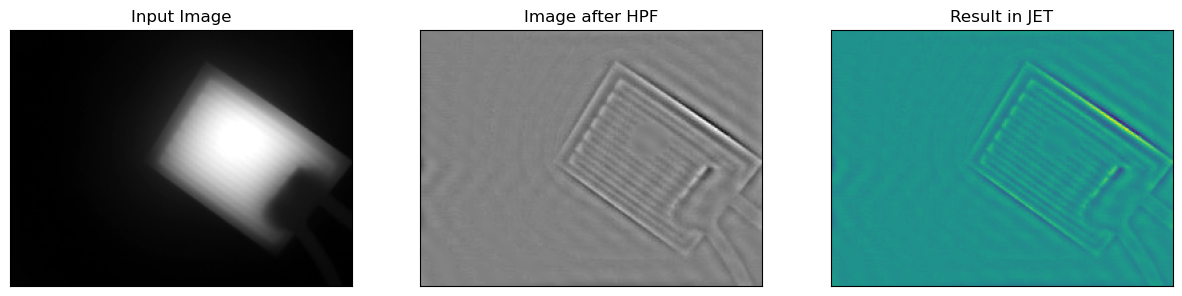

In [32]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2
fshift[crow-12:crow+13, ccol-12:ccol+13] = 0
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.real(img_back)

plt.figure(figsize=(15,5))
plt.subplot(131),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after HPF'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(img_back)
plt.title('Result in JET'), plt.xticks([]), plt.yticks([])

plt.show()

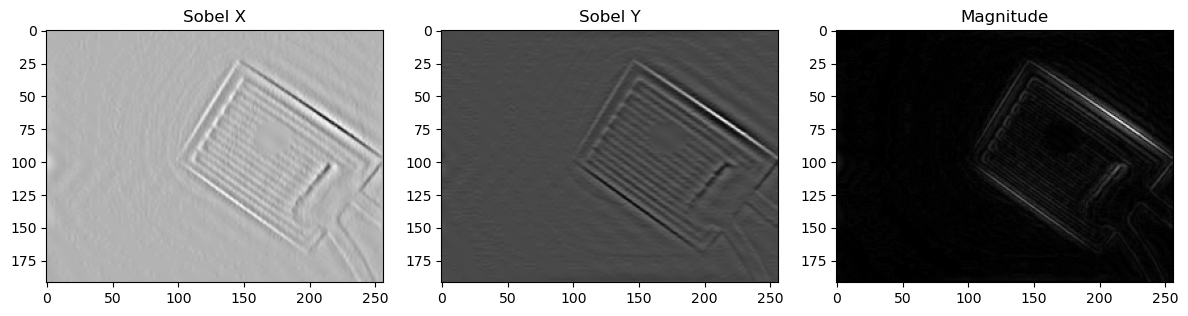

In [33]:
# Применение оператора Собеля по X и Y
sobel_x = cv2.Sobel(img_back, cv2.CV_64F, 1, 0, ksize=3)  # по X
sobel_y = cv2.Sobel(img_back, cv2.CV_64F, 0, 1, ksize=3)  # по Y

# Расчёт полной градиентной величины
sobel_magnitude = cv2.magnitude(sobel_x, sobel_y)
sobel_magnitude = np.uint8(np.clip(sobel_magnitude, 0, 255))

# Отображение
plt.figure(figsize=(12,4))
plt.subplot(1,3,1), plt.imshow(sobel_x, cmap='gray'), plt.title('Sobel X')
plt.subplot(1,3,2), plt.imshow(sobel_y, cmap='gray'), plt.title('Sobel Y')
plt.subplot(1,3,3), plt.imshow(sobel_magnitude, cmap='gray'), plt.title('Magnitude')
plt.tight_layout()
plt.show()

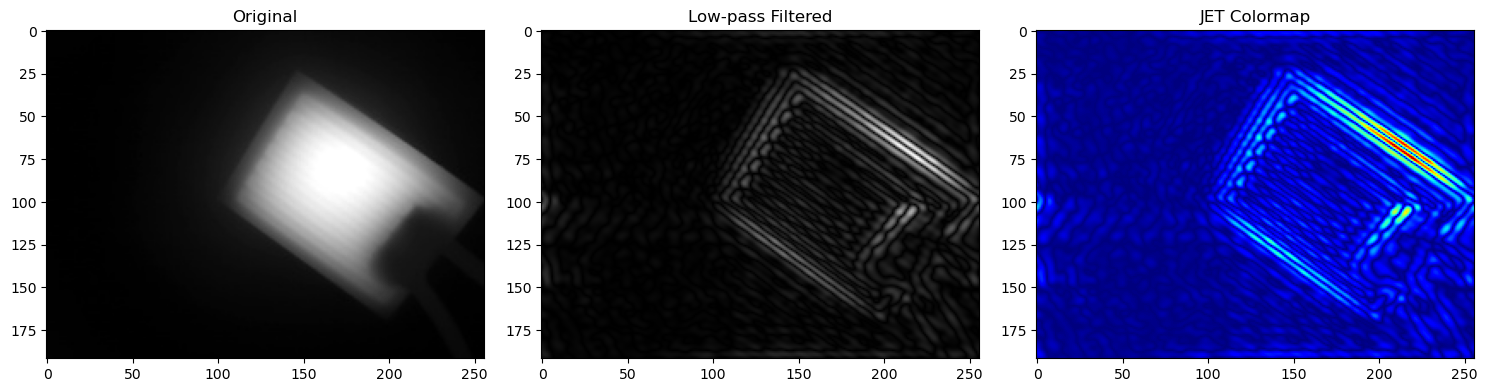

In [34]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
mask = np.zeros_like(fshift, dtype=np.uint8)
radius = 30  # радиус пропускаемой области (низкие частоты)

# Устанавливаем единицы в центральной области
mask[crow - radius:crow + radius + 1, ccol - radius:ccol + radius + 1] = 1

# Применяем маску
fshift_low = fshift * mask

# Обратное Фурье
f_ishift = np.fft.ifftshift(fshift_low)
img_lowpass = np.fft.ifft2(f_ishift)
img_lowpass = np.abs(img_lowpass)

# Отображение
plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(132), plt.imshow(img_lowpass, cmap='gray'), plt.title('Low-pass Filtered')
plt.subplot(133), plt.imshow(img_lowpass, cmap='jet'), plt.title('JET Colormap')
plt.tight_layout()
plt.show()

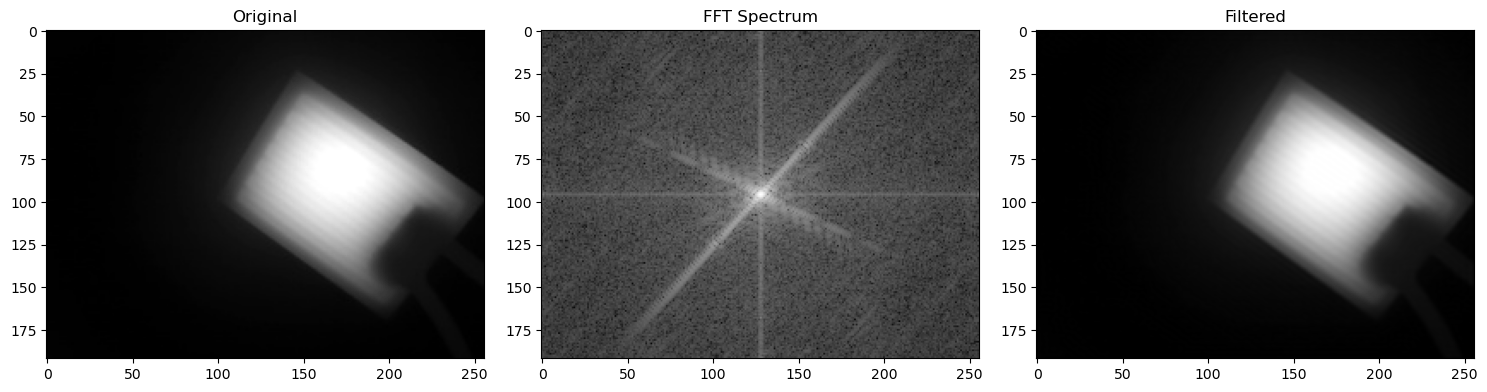

In [35]:
# Преобразуем в частотную область
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# Размеры изображения
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Создание маски: подавим все вне центрального круга (низкие частоты оставим)
mask = np.zeros_like(img, dtype=np.uint8)
cv2.circle(mask, (ccol, crow), 60, 1, thickness=-1)  # радиус подбирается опытным путём

# Применим маску к амплитуде спектра
fshift_filtered = fshift * mask

# Обратное преобразование
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Визуализация
plt.figure(figsize=(15,5))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(132), plt.imshow(np.log(1 + np.abs(fshift)), cmap='gray'), plt.title('FFT Spectrum')
plt.subplot(133), plt.imshow(img_filtered, cmap='gray'), plt.title('Filtered')
plt.tight_layout()
plt.show()


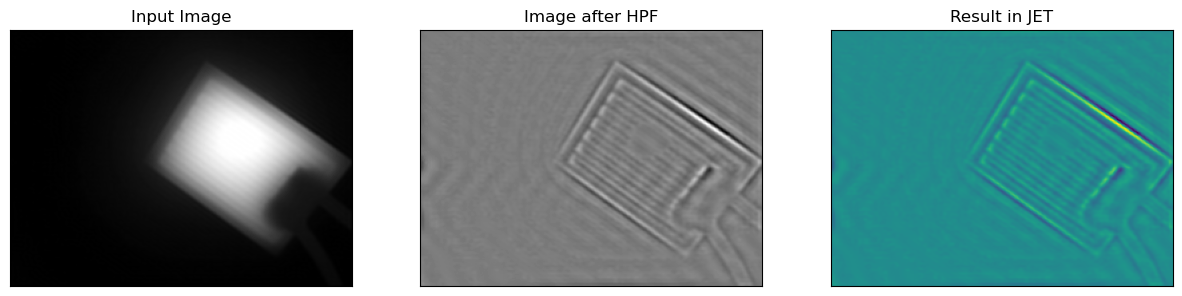

In [36]:
rows, cols = img_filtered.shape
crow, ccol = rows//2, cols//2
f = np.fft.fft2(img_filtered)
fshift = np.fft.fftshift(f)

fshift[crow-12:crow+13, ccol-12:ccol+13] = 0
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.real(img_back)

plt.figure(figsize=(15,5))
plt.subplot(131),plt.imshow(img_filtered, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after HPF'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(img_back)
plt.title('Result in JET'), plt.xticks([]), plt.yticks([])

plt.show()